# System Operation

This notebook demonstrates usage of PyPSA-ZM model for system operation analysis using some basic toolset.


In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import pypsa
import logging
import networkx as nx
logging.getLogger("pypsa.contingency").setLevel(logging.ERROR)


## System Operation


In [ ]:

_candidates = [
    Path("../results/benchmark_run/networks/elec_s_all_ec_lv1.0_Co2L-3h.nc"),
    Path("results/benchmark_run/networks/elec_s_all_ec_lv1.0_Co2L-3h.nc"),
]
network_path = next((p for p in _candidates if p.exists()), _candidates[0])

n = pypsa.Network(str(network_path))
n

INFO:pypsa.io:Imported network elec_s_10_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, links, loads, storage_units


PyPSA Network
Components:
 - Bus: 19
 - Carrier: 13
 - Generator: 55
 - GlobalConstraint: 1
 - Line: 10
 - Link: 12
 - Load: 18
 - StorageUnit: 6
Snapshots: 8760

In [3]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Biomass                  40.00000            40.00000   
            Coal                    330.00000           330.00000   
            Load shedding          2850.55026          2850.55026   
            Oil                     229.60000           229.60000   
            Run of River            138.80000           138.80000   
            Solar                   122.00000           122.00000   
            export                   28.99543            28.99543   
Line        Ac                    19513.63081         19513.63081   
Link        Ac                     6942.00000          6942.00000   
Load        -                         0.00000             0.00000   
            import                    0.00000             0.00000   
StorageUnit Reservoir & Dam        3033.00000          3033.00000   

                                   Supply    Withdrawal  Energy Balance  \
Generator   Biomass          0.000000e+00  0.000000e+00    0.000000e+00   
            Coal             2.012769e+06  0.000000e+00    2.012769e+06   
            Load shedding    0.000000e+00  0.000000e+00    0.000000e+00   
            Oil              0.000000e+00  0.000000e+00    0.000000e+00   
            Run of River     5.278689e+04  0.000000e+00    5.278689e+04   
            Solar            1.791825e+05  0.000000e+00    1.791825e+05   
            export           2.540000e+05  0.000000e+00    2.540000e+05   
Line        Ac               3.686963e+07  3.686963e+07    0.000000e+00   
Link        Ac               1.923640e+07  1.923640e+07    0.000000e+00   
Load        -                0.000000e+00  1.533966e+07   -1.533966e+07   
            import           0.000000e+00  3.660000e+06   -3.660000e+06   
StorageUnit Reservoir & Dam  1.650092e+07  0.000000e+00    1.650092e+07   

                             Transmission  Capacity Factor   Curtailment  \
Generator   Biomass          0.000000e+00         0.000000  3.504000e+05   
            Coal             0.000000e+00         0.696267  8.780311e+05   
            Load shedding    0.000000e+00         0.000000  2.497082e+07   
            Oil              0.000000e+00         0.000000  2.011296e+06   
            Run of River     0.000000e+00         0.043414  0.000000e+00   
            Solar            0.000000e+00         0.167661  0.000000e+00   
            export           0.000000e+00         1.000000  0.000000e+00   
Line        Ac               1.893192e+07         0.215688  0.000000e+00   
Link        Ac              -8.230400e+06         0.316326  0.000000e+00   
Load        -                0.000000e+00              NaN  0.000000e+00   
            import           0.000000e+00              NaN  0.000000e+00   
StorageUnit Reservoir & Dam  0.000000e+00         0.621057  1.006816e+07   

                             Capital Expenditure  Operational Expenditure  \
Generator   Biomass                 2.487973e+06             0.000000e+00   
            Coal                    2.347685e+07             8.072108e+06   
            Load shedding           0.000000e+00             0.000000e+00   
            Oil                     1.230533e+07             0.000000e+00   
            Run of River            1.303184e+07             5.373298e+02   
            Solar                   8.752193e+06             1.717517e+03   
            export                  0.000000e+00             2.352642e+03   
Line        Ac                      1.693579e+10             0.000000e+00   
Link        Ac                      0.000000e+00            -8.427440e+04   
Load        -                       0.000000e+00             0.000000e+00   
            import                  0.000000e+00             0.000000e+00   
StorageUnit Reservoir & Dam         0.000000e+00             1.748698e+07   

                                  Revenue  Market Value  
Generator   Biomass          0.000000e+00      0.000000  
            Coal             8.072108e+06      4

### Spatial structure

Load Distribution

~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


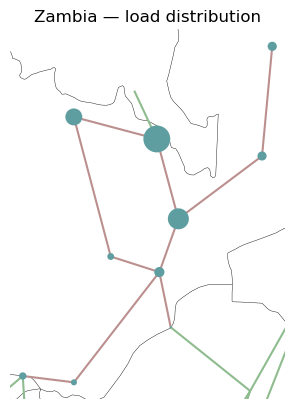

In [4]:
fig, ax = plt.subplots(
    1,
    1,
    subplot_kw={"projection": ccrs.EqualEarth()},
)

load_distribution = n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum()
n.plot(bus_sizes=load_distribution / 6000, ax=ax, title="Zambia — load distribution");

~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/py

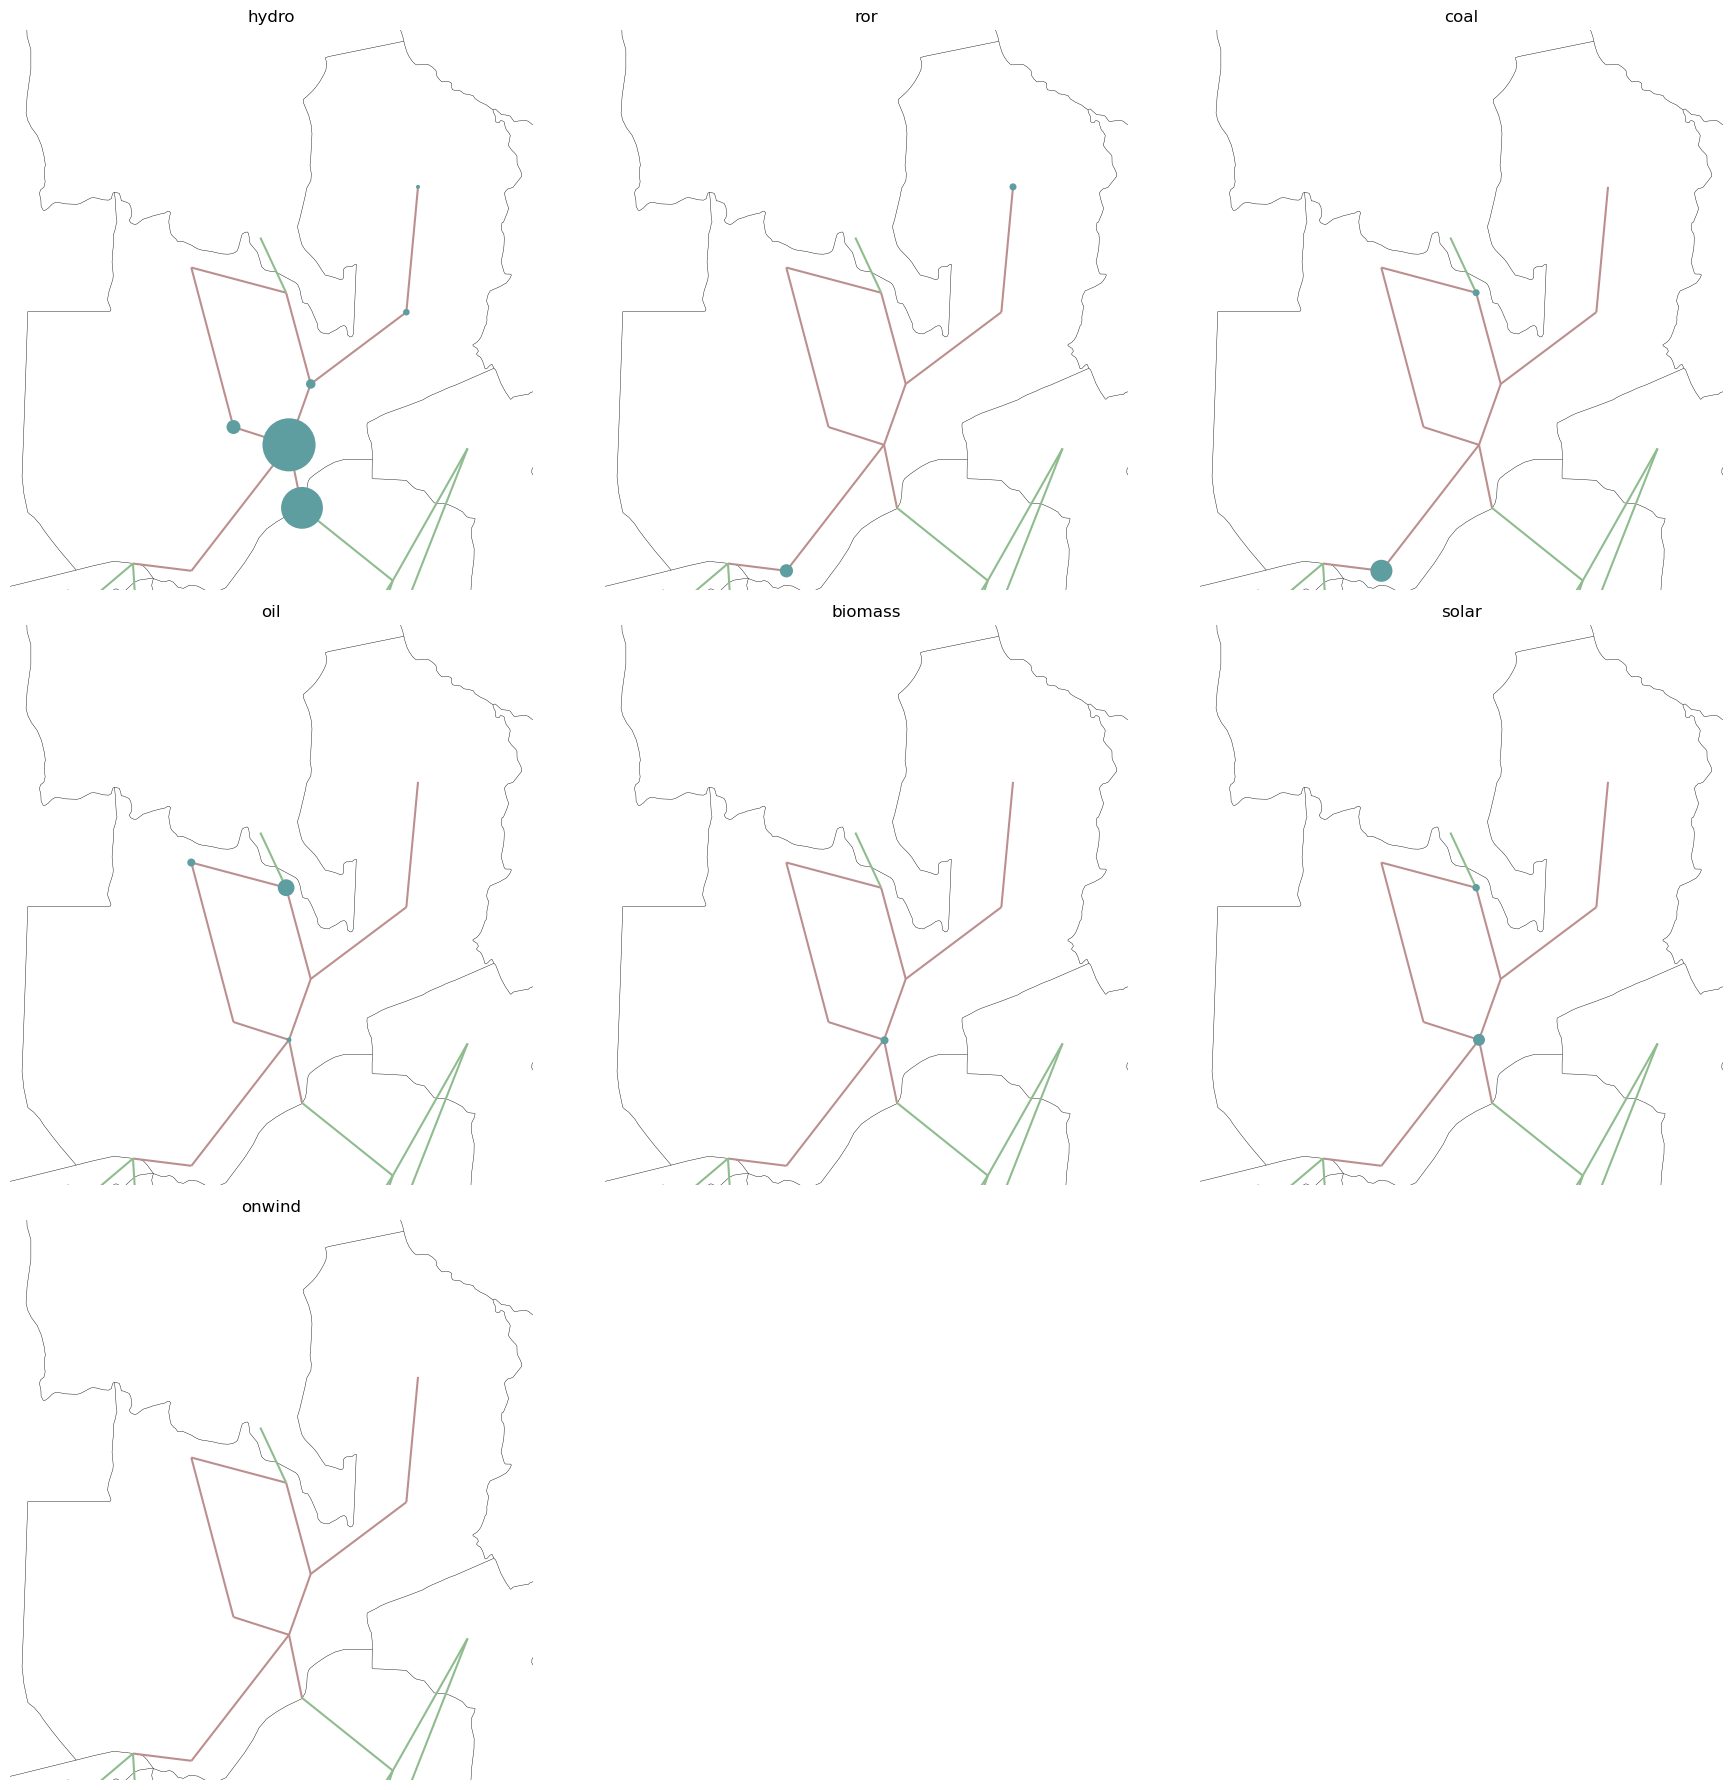

In [5]:
techs = ["hydro", "ror", "coal", "oil", "biomass", "solar", "onwind"]

n_graphs = len(techs)
n_cols = 3
if n_graphs % n_cols == 0:
    n_rows = n_graphs // n_cols
else:
    n_rows = n_graphs // n_cols + 1


fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, subplot_kw={"projection": ccrs.EqualEarth()}
)
size = 6
fig.set_size_inches(size * n_cols, size * n_rows)
axes = axes.flatten()

for i, tech in enumerate(techs):
    ax = axes[i]
    if tech in n.storage_units.carrier.unique():
        units = n.storage_units[n.storage_units.carrier == tech]
    else:
        units = n.generators[n.generators.carrier == tech]
    tech_distribution = (
        units.groupby("bus")["p_nom"].sum().reindex(n.buses.index, fill_value=0)
    )
    n.plot(ax=ax, bus_sizes=tech_distribution / 6000)
    ax.set_title(tech)

    ax.set_extent(
        #[21.5, 34.0, -18.0, -8.0],
        [21.8, 33.8, -18.0, -8.0],
        crs=ccrs.PlateCarree(),
    )    

for j in range(len(techs), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

In [6]:
n.generators.groupby("carrier")["p_nom"].sum().round(1)

carrier
biomass            40.0
coal              330.0
export             29.0
load shedding    2850.6
oil               229.6
onwind              0.0
ror               138.8
solar             122.0
Name: p_nom, dtype: float64

In [7]:
n.storage_units.groupby("carrier")["p_nom"].sum().round(1)

carrier
hydro    3033.0
Name: p_nom, dtype: float64

### Dispatch

In [8]:
gen_dispatch = (
    n.generators_t.p
    .T.groupby(n.generators.carrier)
    .sum()
    .T
)

storage_dispatch = (
    n.storage_units_t.p
    .T.groupby(n.storage_units.carrier)
    .sum()
    .T
)

dispatch = pd.concat(
    [gen_dispatch, storage_dispatch],
    axis=1,
)

In [9]:
dispatch = dispatch.T.groupby(level=0).sum().T

In [10]:
carrier_colors = n.carriers["color"].reindex(dispatch.columns)

In [11]:
carrier_colors["export"] = "orange"

In [12]:
carrier_colors

carrier
biomass          #0c6013
coal             #707070
export            orange
hydro            #08ad97
load shedding    #dd2e23
oil              #262626
onwind           #235ebc
ror              #4adbc8
solar            #f9d002
Name: color, dtype: object

In [13]:
#dispatch_subset = dispatch.loc["2023-07-01":"2023-07-07"]
dispatch_subset = dispatch.loc["2023-09-03":"2023-09-03"]

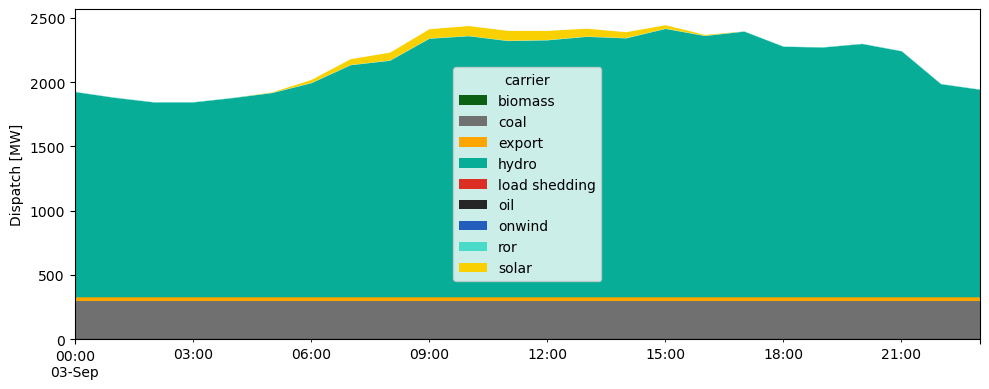

In [14]:
dispatch_pos = dispatch_subset.clip(lower=0)
dispatch_neg = dispatch_subset.clip(upper=0)

fig, ax = plt.subplots(figsize=(10, 4))

dispatch_pos.plot.area(
    ax=ax,
    color=carrier_colors,    
    stacked=True,
    linewidth=0,
)

dispatch_neg.plot.area(
    ax=ax,
    stacked=True,
    linewidth=0,
    legend=False,
)

ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("Dispatch [MW]")
ax.set_xlabel("")

plt.tight_layout()

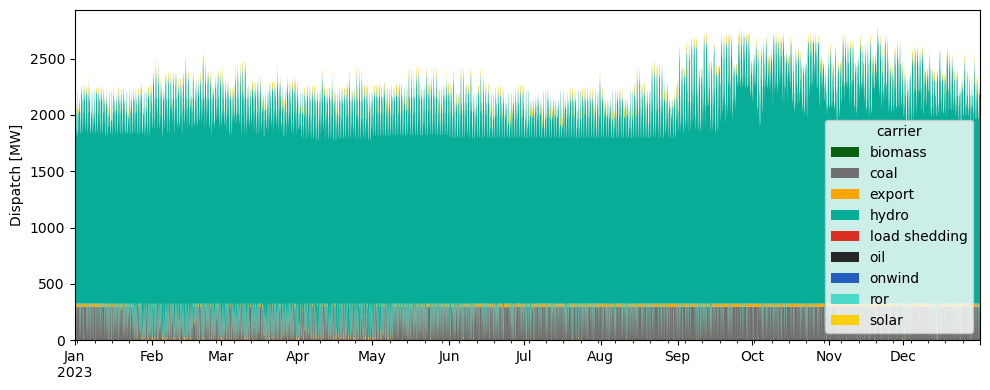

In [15]:
dispatch_pos = dispatch.clip(lower=0)
dispatch_neg = dispatch.clip(upper=0)

fig, ax = plt.subplots(figsize=(10, 4))

dispatch_pos.plot.area(
    ax=ax,
    color=carrier_colors,    
    stacked=True,
    linewidth=0,
)

dispatch_neg.plot.area(
    ax=ax,
    stacked=True,
    linewidth=0,
    legend=False,
)

ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("Dispatch [MW]")
ax.set_xlabel("")

plt.tight_layout()

## Power flow analysis

In [16]:
def plot_network(n, snapshot, ax=None):
    gen_supply = (
        n.generators_t.p.loc[snapshot]
        .groupby(n.generators.bus)
        .sum()
    )

    storage_supply = (
        n.storage_units_t.p.loc[snapshot]
        .clip(lower=0)
        .groupby(n.storage_units.bus)
        .sum()
    )

    bus_size = (
        gen_supply.add(storage_supply, fill_value=0)
        .reindex(n.buses.index, fill_value=0)
    )

    line_flows = pd.concat(
        {"Line": n.lines_t.p0.loc[snapshot]}
    )

    bus_color = n.buses_t.marginal_price.loc[snapshot]

    line_loading = (
        n.lines_t.p0.loc[snapshot].abs()
        / n.lines.s_nom
    )

    n.plot(
        ax=ax,
        bus_sizes=bus_size / 30000,
        bus_colors=bus_color,
        bus_cmap="Reds",
        line_colors=line_loading,
        flow=line_flows / 50,
    )

In [17]:
network_dispatch_path = "~/Documents/_github_/pypsa-zambia/results/dispatch_test_2023_linetype_new_osm_v3_backup/networks/elec_s_22_ec_lv1.0_1h.nc"

n_dispatch = pypsa.Network(network_dispatch_path)

INFO:pypsa.io:Imported network elec_s_22_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, links, loads, storage_units


~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


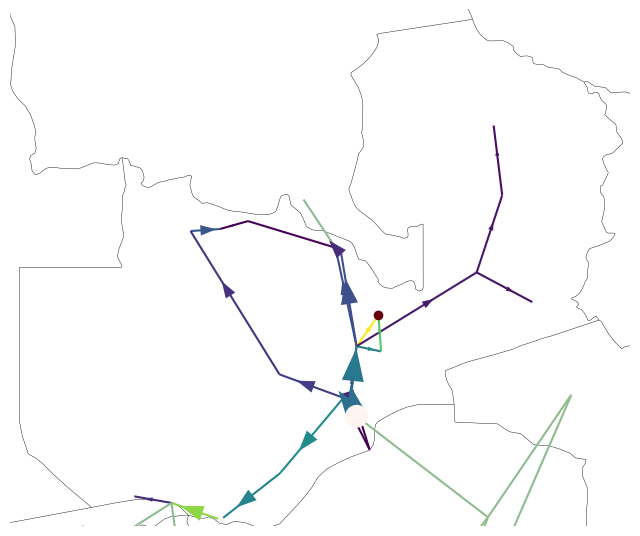

In [18]:
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_network(n_dispatch, "2023-01-01 00:00:00", ax=ax)

ax.set_extent(
    [21.8, 33.8, -18.0, -8.0],
    crs=ccrs.PlateCarree(),
)

plt.show()